# Intent Benchmark

This notebook measures whether GPT-2-small understands the intent behind secure vs.
insecure code, and where in the network that preference lives, across 20 scenarios built from
one flagship CWE-732 (Incorrect Permission Assignment for Critical Resource) S3-ACL pair.

For every scenario we have a **secure_prompt** and an **insecure_prompt** two code strings that
are identical up to the exact point where a security-relevant decision is made (here, the diverging
`"private"` vs. `"public"` ACL value in an `aws_s3_bucket_acl` resource). Four techniques are run on every one:

| Technique | Question it answers |
|---|---|
| **Baseline logit diff** | Given only the shared context, does the model already prefer the secure token over the insecure one, before any intervention? |
| **Logit lens** | Layer by layer, does the model's *internal* representation already encode a secure preference, even where the final output doesn't show it? |
| **DLA (direct logit attribution)** | At the layer where the effect is strongest, which individual attention heads are pushing toward the insecure token? |
| **MLP DLA** | At that same layer, how does the MLP's own contribution compare in sign and magnitude to the summed effect of the attention heads? |

Data source: `Intent_Based_Data.json` — 4 base S3 ACL scenarios, one per structural
`variation_axis` (`naming`, `bucket_ref`, `formatting`, `context_distance`), each crossed with 5
intent framings (`type` A-E: secure-stated, neutral, explicit directive, persona-driven,
remediation-framed) via a prepended `intent_prefix` — 20 entries total. Unlike a purely structural
rewrite check, this dataset deliberately varies the *stated intent* alongside the structure, so it
tests both whether the model's preference survives cosmetic rewrites of the same resource block
and whether stated intent shifts that preference. Every entry also carries a `taxonomy_label`
(e.g. `"Secure Intent, Insecure Output"`) describing the expected relationship between the stated
intent and the code's actual behavior for that framing.

## 1. Setup

In [ ]:
# TransformerLens wraps HookedTransformer models (GPT-2-small here) with named hooks
# into every internal activation (residual stream, attention head outputs, etc.), which is what
# lets us do DLA and logit-lens analysis without touching the model's internals by hand.
!pip install -q transformer_lens transformers einops

In [ ]:
import json
import torch
import pandas as pd
import matplotlib.pyplot as plt
from transformer_lens import HookedTransformer

# device = "cuda" if torch.cuda.is_available() else "cpu"
# print(f"Using device: {device}")
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
model = HookedTransformer.from_pretrained("gpt2-small", device=device)
print(f"Using device: {device}")

# GPT-2-small is a 124M-parameter, 12-layer model — small enough that CPU is usually fine, but
# the MPS fallback still helps on Apple-silicon setups.

# Required before any run_with_cache call that needs per-head outputs (DLA
# below reads blocks.{layer}.attn.hook_result) — must be set before caching,
# not after, or hook_result raises a KeyError.
model.cfg.use_attn_result = True

print(f"Loaded gpt2-small: {model.cfg.n_layers} layers, {model.cfg.n_heads} heads, "
      f"{model.cfg.d_model}-dim residual stream")

## 2. Load the Benchmark Set

Upload `Intent_Based_Data.json` into a `dataset/` folder alongside this notebook (or adjust
`DATASET_PATH` below). It pairs 4 base S3 ACL scenarios (one per variation axis: naming,
bucket_ref, formatting, context_distance) with 5 intent framings each (secure-stated, neutral,
explicit directive, persona-driven, remediation-framed) — 20 entries total. All 20 are tagged
`CWE-732` (Incorrect Permission Assignment for Critical Resource) and carry a `taxonomy_label`
describing the expected intent/output relationship for that framing.

In [ ]:
DATASET_PATH = "dataset/Intent_Based_Data.json"

with open(DATASET_PATH) as f:
    raw_scenarios = json.load(f)

# Intent_Based_Data.json is a flat list of 20 entries: 4 base S3 ACL scenarios (one per
# variation_axis) each crossed with 5 intent framings (type A-E). Each entry's "intent_prefix" is
# identical between its secure_prompt and insecure_prompt, so prepending it to both keeps the
# divergence point exactly the "private" vs "public" token — the rest of the pipeline
# (Sections 3-7) needs no other changes.
#
# Every entry already carries its own "cwe" (CWE-732 for all 20) and "taxonomy_label" via the
# **s spread below, so they don't need to be set here. "type_label" (the intent-framing
# description, e.g. "Secure-stated intent") is renamed to "intent_type" for clarity — it
# describes the framing, not the vulnerability class, so it must not overwrite "cwe".
scenarios = [
    {
        **s,
        "secure_prompt": s["intent_prefix"] + s["secure_prompt"],
        "insecure_prompt": s["intent_prefix"] + s["insecure_prompt"],
        "intent_type": s["type_label"],
    }
    for s in raw_scenarios
]

for s in scenarios:
 print(f" {s['id']:14} | {s['cwe']:9} | {s['intent_type']} | {s['variation_axis']:14} ")

## 3. The Benchmarking Pipeline

Each scenario gives us two full strings, `secure_prompt` and `insecure_prompt`, that are identical
up to the security decision point and then diverge. Rather than assuming *where* they diverge, we
tokenize both and find the point where their token ids actually stop matching this is robust to
cases where the diverging piece is more than one BPE token (e.g. `"defusedxml"` vs. `"xml"`).

Everything before that point is the **shared context** fed to the model. The single token right at
the divergence point in each version is the **secure token** / **insecure token** we track a logit
difference for throughout.

In [ ]:
def find_divergence(model, secure_prompt, insecure_prompt):
    """
    Tokenizes both prompts and finds where their token ids first differ.

    Returns:
        shared_tokens   - tensor of the common prefix (the context both share)
        secure_tok_id   - token id that comes next in the SECURE prompt
        insecure_tok_id - token id that comes next in the INSECURE prompt
    """
    # Tokenize both prompts and find the first divergence point 
    # Convert to integer lists for easier comparison and manipulation
    # Convert it back to tensor for model input
    sec_ids = model.to_tokens(secure_prompt)[0].tolist()
    ins_ids = model.to_tokens(insecure_prompt)[0].tolist()

    shared_len = 0
    for a, b in zip(sec_ids, ins_ids):
        if a != b:
            break
        shared_len += 1

    if shared_len >= len(sec_ids) or shared_len >= len(ins_ids):
        raise ValueError("secure_prompt and insecure_prompt never diverge — check this scenario")

    shared_tokens = torch.tensor([sec_ids[:shared_len]])
    secure_tok_id = sec_ids[shared_len]
    insecure_tok_id = ins_ids[shared_len]

    return shared_tokens, secure_tok_id, insecure_tok_id


In [ ]:
def compute_baseline_logit_diff(model, shared_tokens, secure_tok, insecure_tok, scenario):
    """
    One cached forward pass on the shared context. Returns the cache (reused
    by the logit lens and DLA below — no need to re-run the model three
    times) and the clean baseline logit difference.
    """
    clean_logits, probe_cache = model.run_with_cache(shared_tokens)
    clean_last = clean_logits[0, -1, :]
    baseline_ld = (clean_last[secure_tok] - clean_last[insecure_tok]).item()
    # return probe_cache, baseline_ld

    top_token_id = clean_last.argmax().item()
    print("Model's top predicted next token:", repr(model.to_string([top_token_id])))
    print("type_label / variation_axis:", scenario["type_label"], "/", scenario["variation_axis"])

    # Top-10 ranked candidates, so you can see where the secure/insecure
    # tokens actually sit relative to everything else the model considered.
    top_k = torch.topk(clean_last, 3)
    print("Top 3 candidates:")
    for score, tok_id in zip(top_k.values, top_k.indices):
        print(f"  {score.item():+7.3f}  {repr(model.to_string([tok_id.item()]))}")

    # The two specific scores this dissertation's logit-diff metric compares.
    print("Score for secure_tok  :", clean_last[secure_tok].item(), repr(model.to_string([secure_tok])))
    print("Score for insecure_tok:", clean_last[insecure_tok].item(), repr(model.to_string([insecure_tok])))
    print("Baseline logit diff (secure - insecure):", baseline_ld)
    # --- end debug block ---

    return probe_cache, baseline_ld

In [6]:
def compute_logit_lens(model, probe_cache, secure_tok, insecure_tok):
    """
    Logit lens: project every layer's residual stream straight to logits
    (skipping the layers after it) to see when the secure-preferring
    direction first appears, using logit DIFFERENCES rather than softmax
    probabilities — probabilities are close to zero at every layer here and
    aren't informative at this scale, logit differences are.
    """
    lens_lds = []
    for layer in range(model.cfg.n_layers):
        resid = probe_cache[f"blocks.{layer}.hook_resid_post"][0:1, -1:, :]
        normed = model.ln_final(resid)
        logits = model.unembed(normed).squeeze()
        lens_lds.append((logits[secure_tok] - logits[insecure_tok]).item())
    crossover_layer = next((i for i, v in enumerate(lens_lds) if v > 0), None)
    return lens_lds, crossover_layer

In [7]:
def compute_dla(model, probe_cache, secure_tok, insecure_tok, peak_layer):
    """
    DLA at every layer: project each attention head's output onto the
    secure-vs-insecure unembedding direction, so we can see which heads are
    pushing toward which token.
    """
    unembed_diff = model.W_U[:, secure_tok] - model.W_U[:, insecure_tok]
    unembed_diff = unembed_diff / unembed_diff.norm()
    dla_by_layer = []
    for layer in range(model.cfg.n_layers):
        head_outputs = probe_cache[f"blocks.{layer}.attn.hook_result"][0, -1, :, :]
        dla_by_layer.append((head_outputs @ unembed_diff).tolist())
    top_insecure_heads = torch.argsort(torch.tensor(dla_by_layer[peak_layer]))[:3].tolist()
    return dla_by_layer, top_insecure_heads

In [8]:
def compute_mlp_dla(model, probe_cache, secure_tok, insecure_tok):
    """
    MLP DLA: same projection as compute_dla above, but onto each layer's
    aggregate MLP output (blocks.{layer}.hook_mlp_out) rather than individual
    attention heads. One scalar per layer — the MLP has no head-like
    subunits to break out further.
    """
    unembed_diff = model.W_U[:, secure_tok] - model.W_U[:, insecure_tok]
    unembed_diff = unembed_diff / unembed_diff.norm()
    mlp_dla_by_layer = []
    for layer in range(model.cfg.n_layers):
        mlp_out = probe_cache[f"blocks.{layer}.hook_mlp_out"][0, -1, :]
        mlp_dla_by_layer.append((mlp_out @ unembed_diff).item())
    return mlp_dla_by_layer

In [ ]:
def run_scenario_pipeline(model, scenario):
    """
    Runs baseline logit diff, logit lens, and DLA for one scenario.
    Peak layer is the logit-lens argmax — the layer where the residual
    stream, projected directly to logit space, most prefers the secure token.
    """
    shared_tokens, secure_tok, insecure_tok = find_divergence(
        model, scenario["secure_prompt"], scenario["insecure_prompt"]
    )

    probe_cache, baseline_ld = compute_baseline_logit_diff(
        model, shared_tokens, secure_tok, insecure_tok, scenario
    )

    lens_lds, crossover_layer = compute_logit_lens(model, probe_cache, secure_tok, insecure_tok)

    # Peak layer = where the logit lens logit diff is highest (no steering needed)
    peak_layer = int(torch.tensor(lens_lds).argmax())

    dla_by_layer, top_insecure_heads = compute_dla(
        model, probe_cache, secure_tok, insecure_tok, peak_layer
    )

    mlp_dla_by_layer = compute_mlp_dla(model, probe_cache, secure_tok, insecure_tok)

    return {
        "id": scenario["id"],
        "cwe": scenario["cwe"],
        "intent_type": scenario["intent_type"],
        "variation_axis": scenario["variation_axis"],
        "taxonomy_label": scenario["taxonomy_label"],
        "baseline_ld": baseline_ld,
        "peak_layer": peak_layer,
        "crossover_layer": crossover_layer,
        "top_insecure_heads_at_peak": top_insecure_heads,
        "lens_lds": lens_lds,
        "dla_by_layer": dla_by_layer,
        "mlp_dla_by_layer": mlp_dla_by_layer,
        "mlp_contrib_at_peak": mlp_dla_by_layer[peak_layer],
    }

In [ ]:
for scenario in scenarios:
    secure_prompt = scenario["secure_prompt"]
    insecure_prompt = scenario["insecure_prompt"]

    shared_tokens, secure_tok, insecure_tok = find_divergence(model, secure_prompt, insecure_prompt)

    print("shared_len:", shared_tokens.shape[1])
    print("shared text:", model.to_string(shared_tokens[0]))
    print("secure_tok decoded:", repr(model.to_string([secure_tok])))
    print("insecure_tok decoded:", repr(model.to_string([insecure_tok])))
    print(f"{'=' * 30} {scenario['type_label']} / {scenario['variation_axis']} {'=' * 30}")

## 4. Run the Benchmark

In [ ]:
results = []
failures = []

for scenario in scenarios:
    try:
        r = run_scenario_pipeline(model, scenario)
        results.append(r)
    except Exception as e:
        failures.append((scenario["id"], str(e)))
        print(f"[{scenario['id']:>13}] FAILED: {e}")
    print(f"{'=' * 30} {scenario['type_label']} / {scenario['variation_axis']} {'=' * 30}")

print(f"\n{len(results)}/{len(scenarios)} scenarios completed.")
if failures:
    print("Failed scenarios:", failures)

## 5. Benchmark Table

One row per scenario: CWE tag, intent framing, variation axis, taxonomy label, the baseline
preference, where the logit lens first turns positive, and which heads are actively suppressing
the secure token at the peak layer.

In [ ]:
benchmark_df = pd.DataFrame([
    {
        "id": r["id"],
        "cwe": r["cwe"],
        "intent_type": r["intent_type"],
        "variation_axis": r["variation_axis"],
        "taxonomy_label": r["taxonomy_label"],
        "baseline_ld": round(r["baseline_ld"], 3),
        "peak_layer": r["peak_layer"],
        "logit_lens_crossover_layer": r["crossover_layer"],
        "top_3_insecure_heads_DLA": r["top_insecure_heads_at_peak"],
        "mlp_contribution_at_peak": round(r["mlp_contrib_at_peak"], 3),
    }
    for r in results
]).set_index("id")

benchmark_df.to_csv("intent_benchmark_table.csv")
benchmark_df

## 6. Per-Scenario Comparison

For every scenario: logit lens LD per layer (left), and the DLA head
breakdown at that scenario's peak layer (right). Titles show each scenario's `intent_type`
(e.g. secure-stated, neutral, explicit directive) — compare rows sharing the same `intent_type`
across the four structural variants to see whether phrasing changes the effect, and rows with
different `intent_type` for the same base scenario to see whether stated intent does.

In [ ]:
n = len(results)
fig, axes = plt.subplots(n, 2, figsize=(13, 3.1 * n))
if n == 1:
    axes = axes.reshape(1, 2)

layers_x = range(model.cfg.n_layers)

for row, r in enumerate(results):
    # --- left: logit lens LD per layer ---
    ax_left = axes[row, 0]
    ax_left.plot(layers_x, r["lens_lds"], "o-", color="#9C27B0", linewidth=1.3,
                 label="Logit lens LD")
    ax_left.axhline(r["baseline_ld"], linestyle=":", color="gray",
                    label=f"Baseline LD = {r['baseline_ld']:.2f}")
    ax_left.axhline(0, color="black", linewidth=0.5)
    ax_left.axvline(r["peak_layer"], linestyle="--", color="#9C27B0", alpha=0.4,
                    label=f"Peak layer = {r['peak_layer']}")
    ax_left.set_title(f"{r['id']}  ({r['intent_type']})", fontsize=9)
    ax_left.set_xlabel("Layer", fontsize=8)
    ax_left.set_ylabel("Logit diff", fontsize=8)
    ax_left.tick_params(labelsize=7)
    ax_left.grid(alpha=0.25)
    if row == 0:
        ax_left.legend(fontsize=7)

    # --- right: DLA at this scenario's peak layer (heads + MLP) ---
    ax_right = axes[row, 1]
    peak_contribs = r["dla_by_layer"][r["peak_layer"]]
    n_heads = len(peak_contribs)
    mlp_contrib = r["mlp_contrib_at_peak"]
    all_contribs = peak_contribs + [mlp_contrib]
    colors = ["#F44336" if c < 0 else "#4CAF50" for c in peak_contribs]
    colors.append("#F44336" if mlp_contrib < 0 else "#2196F3")
    xticks = [str(h) for h in range(n_heads)] + ["MLP"]
    bars = ax_right.bar(range(len(all_contribs)), all_contribs, color=colors, alpha=0.85)
    # MLP bar is visually distinct beyond just color — hatched + outlined —
    # so the head-vs-MLP split reads at a glance, including in grayscale.
    bars[-1].set_hatch("///")
    bars[-1].set_edgecolor("black")
    bars[-1].set_linewidth(1.0)
    ax_right.axhline(0, color="black", linewidth=0.5)
    ax_right.set_title(f"DLA at peak layer {r['peak_layer']} (heads + MLP)", fontsize=9)
    ax_right.set_xlabel("Head / MLP", fontsize=8)
    ax_right.set_ylabel("Contribution", fontsize=8)
    ax_right.set_xticks(range(len(all_contribs)))
    ax_right.set_xticklabels(xticks)
    ax_right.tick_params(labelsize=7)
    ax_right.grid(alpha=0.25, axis="y")

plt.tight_layout()
plt.savefig("intent_per_scenario_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Aggregate Summary

Across all scenarios: where across GPT-2-small's 12 layers does the logit lens peak, and what is the baseline preference per scenario.

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ids = [r["id"] for r in results]
baseline_vals = [r["baseline_ld"] for r in results]
bar_colors = ["#4CAF50" if r["baseline_ld"] > 0 else "#F44336" for r in results]

ax1.bar(range(len(results)), baseline_vals, color=bar_colors, alpha=0.8)
ax1.axhline(0, color="black", linewidth=0.6)
ax1.set_xticks(range(len(results)))
ax1.set_xticklabels(ids, rotation=90, fontsize=7)
ax1.set_ylabel("Baseline logit diff (secure − insecure)")
ax1.set_title("Baseline logit diff per scenario\n(green=secure preferred, red=insecure)")
ax1.grid(alpha=0.3, axis="y")

peak_layers = [r["peak_layer"] for r in results]
ax2.hist(peak_layers, bins=range(model.cfg.n_layers + 1), align="left",
         color="#9C27B0", alpha=0.8, rwidth=0.8)
ax2.set_xlabel("Layer")
ax2.set_ylabel("Number of scenarios")
ax2.set_title(f"Logit-lens peak layer distribution across {len(results)} scenarios")
ax2.set_xticks(range(model.cfg.n_layers))
ax2.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("intent_batch_summary.png", dpi=150, bbox_inches="tight")
plt.show()

n_secure = sum(1 for r in results if r["baseline_ld"] > 0)
print(f"Scenarios where baseline already prefers secure token: {n_secure}/{len(results)}")

## 8. Head-Sum vs. MLP Contribution Across Scenarios

Section 6 shows the head-vs-MLP split for one scenario at a time. Here, for every scenario, we
compare the *summed* contribution of all attention heads against the MLP's contribution, both
taken at that scenario's own peak layer — turning "the MLP looks bigger in this one example" into
a battery-wide count of how often that holds.

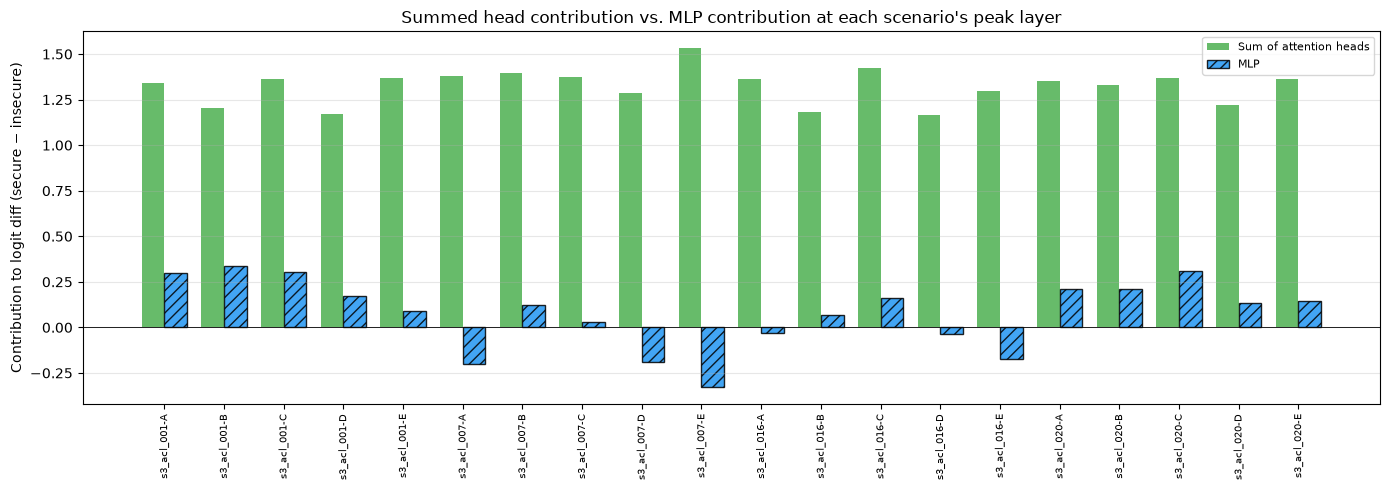

MLP contribution exceeds the summed head contribution (by magnitude) at the peak layer in 0/20 scenarios.


In [14]:
head_sum_at_peak = [sum(r["dla_by_layer"][r["peak_layer"]]) for r in results]
mlp_at_peak = [r["mlp_contrib_at_peak"] for r in results]
ids = [r["id"] for r in results]

x = range(len(results))
width = 0.38

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar([i - width / 2 for i in x], head_sum_at_peak, width,
       color="#4CAF50", alpha=0.85, label="Sum of attention heads")
bars_mlp = ax.bar([i + width / 2 for i in x], mlp_at_peak, width,
                   color="#2196F3", alpha=0.85, label="MLP")
for b in bars_mlp:
    b.set_hatch("///")
    b.set_edgecolor("black")
    b.set_linewidth(1.0)

ax.axhline(0, color="black", linewidth=0.6)
ax.set_xticks(list(x))
ax.set_xticklabels(ids, rotation=90, fontsize=7)
ax.set_ylabel("Contribution to logit diff (secure − insecure)")
ax.set_title("Summed head contribution vs. MLP contribution at each scenario's peak layer")
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("intent_head_vs_mlp.png", dpi=150, bbox_inches="tight")
plt.show()

n_mlp_dominant = sum(1 for h, m in zip(head_sum_at_peak, mlp_at_peak) if abs(m) > abs(h))
print(f"MLP contribution exceeds the summed head contribution (by magnitude) at the peak layer "
      f"in {n_mlp_dominant}/{len(results)} scenarios.")

## Notes for interpreting these results

- **20 scenarios cross two axes of one flagship CWE-732 pair** — 4 structural rewrites
  (`variation_axis`: `naming`, `bucket_ref`, `formatting`, `context_distance` — renamed resources,
  alternate bucket references, meta-arguments/whitespace, and surrounding context) × 5 intent
  framings (`intent_type`: secure-stated, neutral, explicit directive, persona-driven,
  remediation-framed). Every `secure_prompt`/`insecure_prompt` pair still diverges on the same
  `"private"` vs. `"public"` ACL token. A consistent sign within the same `intent_type` across all
  four structural variants is evidence the baseline preference is a genuine pattern rather than an
  artifact of one specific way of writing the resource block; a shift in sign across `intent_type`
  for the same base scenario is evidence stated intent itself moves the model's preference. Each
  entry's `taxonomy_label` (e.g. `"Secure Intent, Insecure Output"`) states what relationship
  between stated intent and code behavior that framing was designed to test.
- **DLA covers attention heads and the MLP's aggregate contribution** — `compute_mlp_dla`
  projects each layer's MLP output onto the same secure-vs-insecure unembedding direction used
  for heads, and `mlp_contribution_at_peak` reports it at the scenario's peak layer (also plotted
  as the rightmost "MLP" bar alongside the heads). The MLP is not broken down further internally
  (e.g. by neuron) — this gives its total per-layer effect, not which parts of it drive that
  effect.